In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install pandas torch transformers matplotlib seaborn prettytable

In [6]:
import pandas as pd

# Utiliser deux barres obliques inverses pour échapper correctement
file_path = r'C:\Users\user\Desktop\python\predictive analytics project\DATA_Reviews.csv'

df = pd.read_csv(file_path)

df
    


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
1,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
2,13,B0009XLVG0,A327PCT23YH90,LT,1,1,1,1339545600,My Cats Are Not Fans of the New Food,My cats have been happily eating Felidae Plati...
3,17,B001GVISJM,A3KLWF6WQ5BNYO,Erica Neathery,0,0,2,1348099200,poor taste,I love eating them and they are good for watch...
4,27,B001GVISJM,A3RXAU2N8KV45G,lady21,0,1,1,1332633600,Nasty No flavor,"The candy is just red , No flavor . Just plan..."
...,...,...,...,...,...,...,...,...,...,...
4495,1902,B001RVFDOO,A1D40O74QROUL3,DroidManiac,0,0,4,1332115200,Most flavors are very good,I bought these to try them out and for the mos...
4496,1903,B001RVFDOO,AQNX0WN00JEVE,C. Thilmany,0,0,4,1331424000,Great idea,This practically falls under the category of h...
4497,1904,B001RVFDOO,A2UV6EZRAAXJB9,A. R. Martinez,0,0,5,1331164800,"Healthy and Good, What?!?!","Yes people, these things are healthier than th..."
4498,1905,B001RVFDOO,A6L5LH8M17JS,sbssis1,0,0,5,1330905600,Healthy and Delicious!,Tried the BBQ Popchips for the first time and ...


In [9]:
# Import necessary libraries
import pandas as pd
import torch
from transformers import BertTokenizer, BertForSequenceClassification, AdamW
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check if CUDA is available and set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load the dataset
file_path = r'C:\Users\user\Desktop\python\predictive analytics project\DATA_Reviews.csv' # Adjust the file path
df = pd.read_csv(file_path)

# Keep only text and score columns
df = df[['Text', 'Score']]  # Adjust column names if needed

# Rewrite scores to sentiment labels
def score_to_sentiment(score):
    if score in [1, 2]:
        return 'negative'
    elif score == 3:
        return 'neutral'
    elif score in [4, 5]:
        return 'positive'

df['sentiment'] = df['Score'].apply(score_to_sentiment)

# Encode sentiment labels to numerical values
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment'].map(label_map)

In [10]:
df

,Text,Score,sentiment,label
0,Product arrived labeled as Jumbo Salted Peanut...,1,negative,0
1,If you are looking for the secret ingredient i...,2,negative,0
2,My cats have been happily eating Felidae Plati...,1,negative,0
3,I love eating them and they are good for watch...,2,negative,0
4,"The candy is just red , No flavor . Just plan...",1,negative,0
...,...,...,...,...
4495,I bought these to try them out and for the mos...,4,positive,2
4496,This practically falls under the category of h...,4,positive,2
4497,"Yes people, these things are healthier than th...",5,positive,2
4498,Tried the BBQ Popchips for the first time and ...,5,positive,2


In [11]:
# Count the number of negative, neutral, and positive sentiments
sentiment_counts = df['sentiment'].value_counts()

# Display the counts
print("Number of Negative Sentiments:", sentiment_counts['negative'])
print("Number of Neutral Sentiments:", sentiment_counts['neutral'])
print("Number of Positive Sentiments:", sentiment_counts['positive'])


Number of Negative Sentiments: 1500
Number of Neutral Sentiments: 1500
Number of Positive Sentiments: 1500


In [12]:
df.head()

,Text,Score,sentiment,label
0,Product arrived labeled as Jumbo Salted Peanut...,1,negative,0
1,If you are looking for the secret ingredient i...,2,negative,0
2,My cats have been happily eating Felidae Plati...,1,negative,0
3,I love eating them and they are good for watch...,2,negative,0
4,"The candy is just red , No flavor . Just plan...",1,negative,0


In [6]:
# Convert text columns to strings and handle NaN values
df['Text'] = df['Text'].astype(str).fillna('')

# Split the dataset into training and validation sets
train_texts, val_texts, train_labels, val_labels = train_test_split(df['Text'], df['label'], test_size=0.2, random_state=42)

In [7]:
#label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=len(label_map))
model.to(device)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [8]:
# Tokenize the data and create DataLoader
train_encodings = tokenizer(train_texts.tolist(), truncation=True, padding=True, max_length=128, return_tensors='pt')
val_encodings = tokenizer(val_texts.tolist(), truncation=True, padding=True, max_length=128, return_tensors='pt')

# Create TensorDatasets
train_dataset = TensorDataset(train_encodings['input_ids'], train_encodings['attention_mask'], torch.tensor(train_labels.values))
val_dataset = TensorDataset(val_encodings['input_ids'], val_encodings['attention_mask'], torch.tensor(val_labels.values))

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

In [9]:
# Fine-tuning
optimizer = AdamW(model.parameters(), lr=1e-5)

for epoch in range(2):
    model.train()
    for batch in train_loader:
        input_ids, attention_mask, labels = batch
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    total = correct = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids, attention_mask, labels = batch
            input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            predictions = torch.argmax(outputs.logits, dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    print(f'Epoch {epoch+1}: Validation Accuracy = {correct/total:.5f}')

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1: Validation Accuracy = 0.73333
Epoch 2: Validation Accuracy = 0.76556
Epoch 3: Validation Accuracy = 0.76778


In [10]:
final_predictions_list = []
final_true_labels_list = []
for batch in val_loader:
    input_ids, attention_mask, label_ids = batch
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=1)
    final_predictions_list.extend(predictions.cpu().numpy())
    final_true_labels_list.extend(label_ids.cpu().numpy())

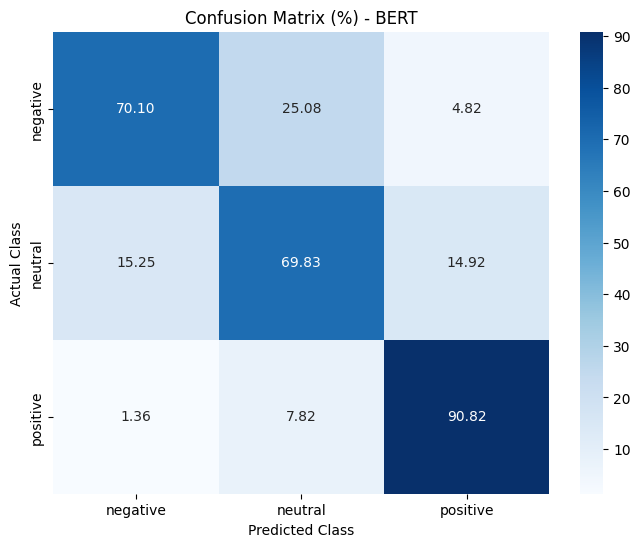

In [11]:
final_cm = confusion_matrix(final_true_labels_list, final_predictions_list)
final_cm_percentage = final_cm.astype('float') / final_cm.sum(axis=1)[:, np.newaxis] * 100

class_labels = ['negative', 'neutral', 'positive']

plt.figure(figsize=(8, 6))
sns.heatmap(final_cm_percentage, annot=True, cmap='Blues', fmt='.2f', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix (%) - BERT')
plt.show()

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(final_true_labels_list, final_predictions_list)
precision = precision_score(final_true_labels_list, final_predictions_list, average='weighted')
recall = recall_score(final_true_labels_list, final_predictions_list, average='weighted')
f1 = f1_score(final_true_labels_list, final_predictions_list, average='weighted')
classification_rep = classification_report(final_true_labels_list, final_predictions_list, target_names=list(label_map.keys()), digits=4)

from prettytable import PrettyTable

table = PrettyTable()
table.field_names = ["Metric", "Score"]
table.add_row(["Accuracy", f'{accuracy:.4f}'])
table.add_row(["Precision", f'{precision:.4f}'])
table.add_row(["Recall", f'{recall:.4f}'])
table.add_row(["F1 Score", f'{f1:.4f}'])

print("Evaluation Metrics:")
print(table)
print("\nClassification Report:\n")
print(classification_rep)

Evaluation Metrics:
+-----------+--------+
|   Metric  | Score  |
+-----------+--------+
|  Accuracy | 0.7678 |
| Precision | 0.7696 |
|   Recall  | 0.7678 |
|  F1 Score | 0.7663 |
+-----------+--------+

Classification Report:

              precision    recall  f1-score   support

    negative     0.8165    0.7010    0.7543       311
     neutral     0.6710    0.6983    0.6844       295
    positive     0.8190    0.9082    0.8613       294

    accuracy                         0.7678       900
   macro avg     0.7688    0.7691    0.7667       900
weighted avg     0.7696    0.7678    0.7663       900

